# Determine Per-Marker Binary Thresholds

This notebook computes **per-marker** positive/negative thresholds using two automated methods:

- **Otsu's method** — maximises between-class variance on the log-intensity histogram; works well for bimodal distributions
- **GMM (2-component Gaussian Mixture)** — fits background + signal Gaussians in log space; threshold = background μ + 2σ

You inspect the plots, optionally override individual markers in `MANUAL_OVERRIDES`, then save
`output/gating_thresholds.csv`. That CSV is loaded by `build_protein_cell_matrix_h5ad.ipynb` to
produce a biologically meaningful `layers["binary"]`.

**DAPI / DAPI2 are not gated.** Cells are already defined by DAPI-based Cellpose masks; nuclear
channels remain in the continuous H5AD for QC/visualization only.

---

## Pipeline position

```
determine_binary_threshold.ipynb  ← YOU ARE HERE
    ↓  writes output/gating_thresholds.csv
build_protein_cell_matrix_h5ad.ipynb
    ↓  writes output/celldive_protein_matrix.h5ad
analyze_cell_types_from_markers.ipynb
```

## Why per-marker thresholds?

A single global percentile (e.g. p25) calls **75 % of cells positive** for *every* marker, regardless of how
rare the true signal is.  For CD11c or CD31 — which are nearly zero in most cells — p25 produces a
biologically meaningless call.  Per-marker thresholds respect each marker's actual dynamic range.

## Inputs / Outputs

| | Path | Description |
|---|---|---|
| **In** | `output/celldive_protein_matrix_continuous.h5ad` | Continuous intensities (float32) |
| **Out** | `output/gating_thresholds.csv` | Per-marker threshold values (protein markers only; no DAPI) |


## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad

try:
    from sklearn.mixture import GaussianMixture
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("scikit-learn not available — GMM method will be skipped, Otsu will be used.")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONTINUOUS_H5AD = PROJECT_ROOT / "output" / "celldive_protein_matrix_continuous.h5ad"
GATING_CSV_OUT  = PROJECT_ROOT / "output" / "gating_thresholds.csv"

print(f"Project root : {PROJECT_ROOT}")
print(f"Continuous H5AD : {CONTINUOUS_H5AD}")
print(f"Output CSV   : {GATING_CSV_OUT}")

Project root : /home/steve/Projects/HeLab/BladderDIVE
Continuous H5AD : /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix_continuous.h5ad
Output CSV   : /home/steve/Projects/HeLab/BladderDIVE/output/gating_thresholds.csv


## 2. Load Continuous Data

If `celldive_protein_matrix_continuous.h5ad` is missing, run the cell below the load cell
to rebuild it from zarr (~15 min).  If the file already exists it will be loaded directly.

In [2]:
if CONTINUOUS_H5AD.exists():
    print(f"Found: {CONTINUOUS_H5AD.name} — loading...")
else:
    raise FileNotFoundError(
        f"{CONTINUOUS_H5AD.name} not found.\n"
        "Run the 'Create Continuous H5AD' cell at the bottom of this notebook "
        "(requires zarr + mask, ~15 min)."
    )

adata = ad.read_h5ad(CONTINUOUS_H5AD)
X = np.asarray(adata.X, dtype=np.float32)
var_names = list(adata.var_names)
n_cells = adata.n_obs

# Guard against accidentally loading a binary file
unique_vals = np.unique(X)
if len(unique_vals) <= 2 and set(unique_vals.tolist()).issubset({0.0, 1.0}):
    raise ValueError(
        f"{CONTINUOUS_H5AD.name} appears to contain binary (0/1) data.\n"
        "Delete it and run the 'Create Continuous H5AD' cell below to rebuild."
    )

print(f"Cells: {n_cells:,}   Proteins: {len(var_names)}")
print(f"Intensity range: [{X.min():.1f}, {X.max():.1f}]")
print(f"Markers: {var_names}")

Found: celldive_protein_matrix_continuous.h5ad — loading...
Cells: 926,006   Proteins: 23
Intensity range: [0.0, 65534.0]
Markers: ['DAPI', 'CD45', 'CD3E', 'Ki67', 'CD8a', 'VIM', 'CD68', 'HLADR', 'CD31', 'ACTA2', 'CD20', 'CD163', 'CD44', 'PANCK', 'CD38', 'CD11c', 'PDGFRA', 'COL1A1', 'CD14', 'EPCAM', 'CD56', 'CD45RO', 'DAPI2']


## 3. Per-Marker Threshold Methods

### Otsu's method
Maximises between-class variance on a histogram of **log1p(positive intensities)**.  
Does not require scikit-learn.  Works well when the distribution is clearly bimodal.

### GMM (2-component Gaussian Mixture)
Fits two Gaussians in log1p space — one for background, one for signal.  
Threshold = background μ + `GMM_N_SIGMA` × background σ (default 2).  
More flexible than Otsu for asymmetric distributions, but can fail for near-unimodal markers.

Both methods operate on **positive intensities only** (X > 0) to exclude structural zeros.

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Number of background standard deviations above background mean used as GMM threshold.
# 2.0 is a common choice (≈97.7th percentile of background distribution).
GMM_N_SIGMA = 2.0

# Bimodality gate: minimum separation score D = |μ_signal - μ_bg| / √((σ_bg² + σ_signal²)/2)
# needed before we trust the GMM result. D < 1.0 means the two Gaussian components overlap
# so heavily that the distribution is effectively unimodal and GMM cannot find a real valley.
MIN_GMM_SEPARATION = 1.0

# Nuclear channels: excluded from thresholding and gating CSV (Cellpose already defined cells).
SKIP_MARKERS = {"DAPI", "DAPI2"}

gating_markers = [n for n in var_names if n not in SKIP_MARKERS]
print(f"Gating markers ({len(gating_markers)}): {gating_markers}")
if SKIP_MARKERS & set(var_names):
    print(f"Skipped (not gated): {sorted(SKIP_MARKERS & set(var_names))}")

# ── Otsu ──────────────────────────────────────────────────────────────────────
def otsu_threshold_log(values: np.ndarray, n_bins: int = 256) -> float | None:
    """Otsu threshold on log1p(positive values). Returns linear-scale threshold."""
    pos = values[values > 0]
    if pos.size < 50:
        return None
    pos_log = np.log1p(pos.astype(np.float64))
    n_bins = min(n_bins, max(32, int(np.sqrt(pos.size))))
    counts, edges = np.histogram(pos_log, bins=n_bins)
    total = float(counts.sum())
    if total == 0:
        return None

    best_var, best_thresh_log = -np.inf, None
    w0, sum0 = 0.0, 0.0
    bin_centers = (edges[:-1] + edges[1:]) / 2
    total_sum = float(np.sum(counts * bin_centers))

    for i in range(len(counts) - 1):
        w0 += counts[i]
        w1 = total - w0
        if w0 == 0 or w1 == 0:
            continue
        sum0 += counts[i] * bin_centers[i]
        mu0 = sum0 / w0
        mu1 = (total_sum - sum0) / w1
        var_b = (w0 / total) * (w1 / total) * (mu0 - mu1) ** 2
        if var_b > best_var:
            best_var = var_b
            best_thresh_log = edges[i + 1]

    return float(np.expm1(best_thresh_log)) if best_thresh_log is not None else None


# ── GMM ───────────────────────────────────────────────────────────────────────
def gmm_fit_log(values: np.ndarray, n_sigma: float = 2.0) -> dict:
    """
    Fit a 2-component GMM in log1p space.

    Returns a dict with keys:
      threshold   – linear-scale threshold (background μ + n_sigma × background σ)
      separation  – Fisher-like separation D = |μ_signal - μ_bg| / √((σ_bg² + σ_signal²)/2)
                    Values > 1 indicate the peaks are well-separated (bimodal).
                    Values < 1 indicate heavy overlap (effectively unimodal).
    Both values are None if fitting failed.
    """
    if not HAS_SKLEARN:
        return {"threshold": None, "separation": None}
    pos = values[values > 0]
    if pos.size < 200:
        return {"threshold": None, "separation": None}
    pos_log = np.log1p(pos.astype(np.float64)).reshape(-1, 1)
    try:
        gmm = GaussianMixture(n_components=2, random_state=42, n_init=5, max_iter=300)
        gmm.fit(pos_log)
        means = gmm.means_.flatten()
        stds  = np.sqrt(gmm.covariances_.flatten())
        bg_idx  = int(np.argmin(means))
        sig_idx = 1 - bg_idx
        thresh_log = means[bg_idx] + n_sigma * stds[bg_idx]
        # Fisher-like separation score between the two components
        pooled_std = np.sqrt((stds[bg_idx]**2 + stds[sig_idx]**2) / 2)
        separation = float(abs(means[sig_idx] - means[bg_idx]) / pooled_std) if pooled_std > 0 else 0.0
        return {
            "threshold":  float(np.expm1(thresh_log)),
            "separation": round(separation, 2),
        }
    except Exception:
        return {"threshold": None, "separation": None}


# ── Compute per-marker thresholds ────────────────────────────────────────────
print("Computing Otsu and GMM thresholds per marker...")
print(f"  Bimodality threshold: separation ≥ {MIN_GMM_SEPARATION} (otherwise GMM is ignored)\n")
rows = []
for name in gating_markers:
    col = X[:, var_names.index(name)]
    otsu    = otsu_threshold_log(col)
    fit     = gmm_fit_log(col, n_sigma=GMM_N_SIGMA)
    gmm     = fit["threshold"]
    sep     = fit["separation"]
    bimodal = (sep is not None) and (sep >= MIN_GMM_SEPARATION)
    p25  = float(np.percentile(col[col > 0], 25)) if (col > 0).any() else None
    p75  = float(np.percentile(col[col > 0], 75)) if (col > 0).any() else None
    p90  = float(np.percentile(col[col > 0], 90)) if (col > 0).any() else None
    rows.append(dict(
        marker=name,
        otsu=round(otsu, 1)  if otsu is not None else None,
        gmm=round(gmm, 1)    if gmm  is not None else None,
        gmm_separation=sep,
        is_bimodal=bimodal,
        p25=round(p25, 1)    if p25  is not None else None,
        p75=round(p75, 1)    if p75  is not None else None,
        p90=round(p90, 1)    if p90  is not None else None,
    ))
    flag = "✓ bimodal" if bimodal else "✗ unimodal"
    print(f"  {name:<12}  sep={str(sep):<6}  {flag:<14}  "
          f"otsu={str(round(otsu,1) if otsu else 'N/A'):<10}  "
          f"gmm={str(round(gmm,1) if gmm else 'N/A'):<10}  p90={str(round(p90,1) if p90 else 'N/A')}")

thresh_df = pd.DataFrame(rows)
n_bimodal   = thresh_df["is_bimodal"].sum()
n_unimodal  = (~thresh_df["is_bimodal"]).sum()
print(f"\nBimodal: {n_bimodal}   Unimodal/ambiguous: {n_unimodal}  → unimodal markers need manual review")


Gating markers (21): ['CD45', 'CD3E', 'Ki67', 'CD8a', 'VIM', 'CD68', 'HLADR', 'CD31', 'ACTA2', 'CD20', 'CD163', 'CD44', 'PANCK', 'CD38', 'CD11c', 'PDGFRA', 'COL1A1', 'CD14', 'EPCAM', 'CD56', 'CD45RO']
Skipped (not gated): ['DAPI', 'DAPI2']
Computing Otsu and GMM thresholds per marker...
  Bimodality threshold: separation ≥ 1.0 (otherwise GMM is ignored)

  CD45          sep=1.9     ✓ bimodal       otsu=88.9        gmm=494.8       p90=1165.5
  CD3E          sep=2.12    ✓ bimodal       otsu=129.3       gmm=655.6       p90=5111.2
  Ki67          sep=0.73    ✗ unimodal      otsu=55.0        gmm=512.6       p90=147.1
  CD8a          sep=2.54    ✓ bimodal       otsu=121.6       gmm=344.5       p90=1995.6
  VIM           sep=2.05    ✓ bimodal       otsu=724.5       gmm=2351.2      p90=4256.1
  CD68          sep=0.45    ✗ unimodal      otsu=264.1       gmm=269.3       p90=436.0
  HLADR         sep=1.83    ✓ bimodal       otsu=393.0       gmm=217.2       p90=1709.0
  CD31          sep=3.03    ✓

## 4. Visualize Gating Markers

Histograms for **protein markers only** (DAPI / DAPI2 omitted — see intro).

Each panel shows a **log-scale y-axis count histogram of positive intensities** with up to three
threshold lines:

| Line | Colour | Method |
|------|--------|--------|
| Otsu | green dashed | Between-class variance maximum |
| GMM  | purple dashed | Background μ + 2σ in log1p space |
| p90  | tomato dotted | p90 of positives (unimodal fallback) |

Look for the **valley** between background and signal peaks.  A good threshold sits in that valley.
If Otsu or GMM is far from the valley, add a manual override in Section 6.


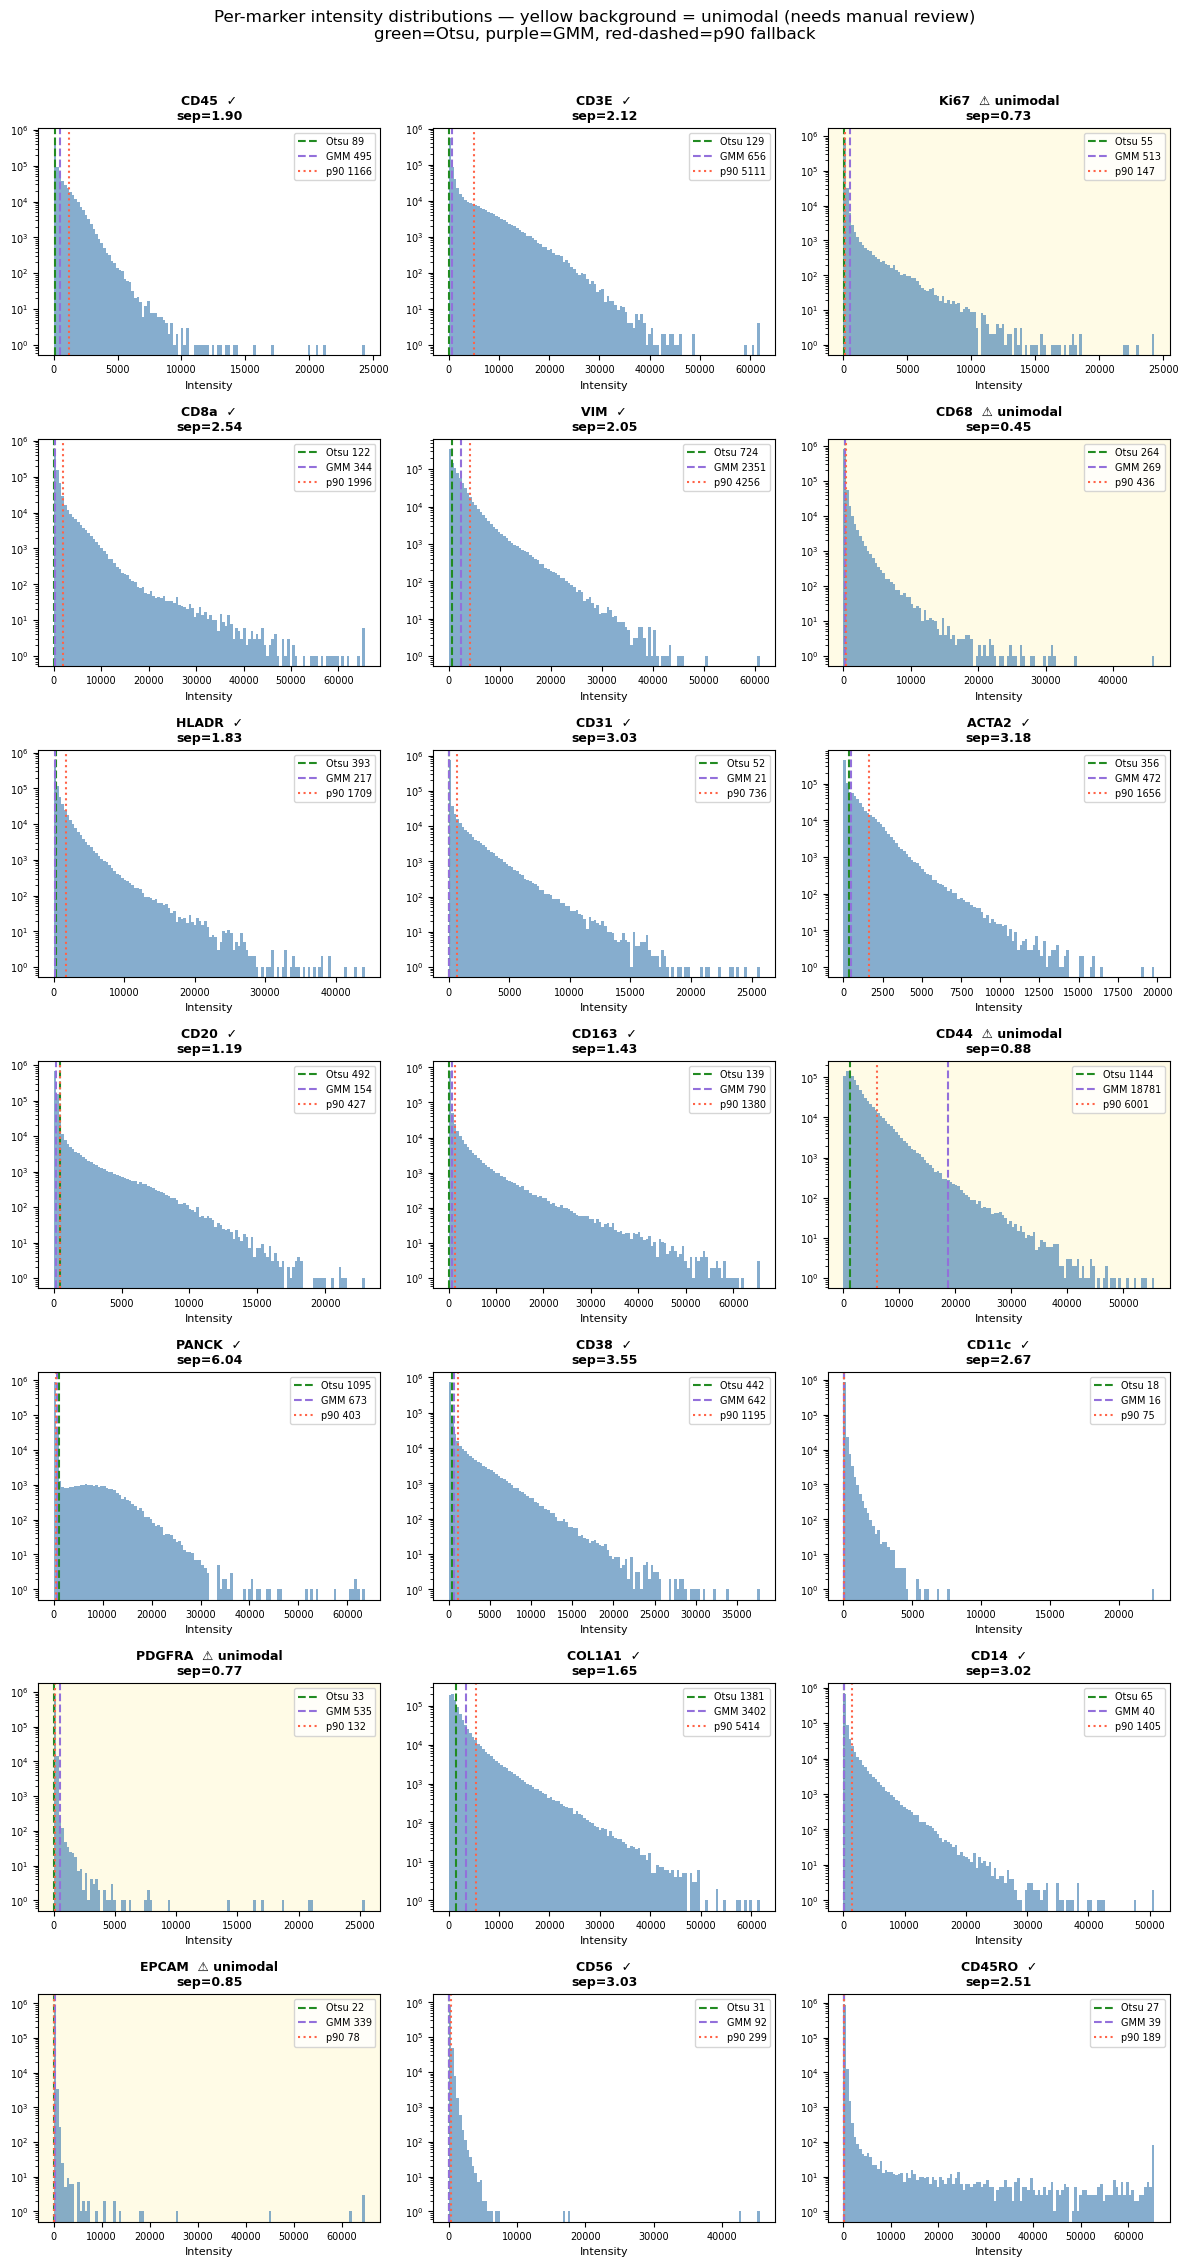

Figure saved → /home/steve/Projects/HeLab/BladderDIVE/output/figures/threshold_histograms.png


In [4]:
plot_markers = gating_markers
n_markers = len(plot_markers)
ncols = 3
nrows = int(np.ceil(n_markers / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.2))
axes = axes.ravel()

for i, name in enumerate(plot_markers):
    ax = axes[i]
    col = X[:, var_names.index(name)]
    pos = col[col > 0]
    row = thresh_df[thresh_df["marker"] == name].iloc[0]

    # Yellow background for unimodal markers that need manual review
    if not row["is_bimodal"]:
        ax.set_facecolor("#fffbe6")

    if pos.size > 0:
        ax.hist(pos, bins=120, color="steelblue", alpha=0.65, edgecolor="none",
                log=True, density=False)

    if row["otsu"] is not None:
        ax.axvline(row["otsu"], color="forestgreen", linestyle="--", lw=1.5, label=f"Otsu {row['otsu']:.0f}")
    if row["gmm"] is not None:
        ax.axvline(row["gmm"],  color="mediumpurple", linestyle="--", lw=1.5, label=f"GMM {row['gmm']:.0f}")
    if row["p90"] is not None:
        ax.axvline(row["p90"],  color="tomato",       linestyle=":",  lw=1.5, label=f"p90 {row['p90']:.0f}")

    sep_str = f"sep={row['gmm_separation']:.2f}" if row["gmm_separation"] is not None else ""
    bimodal_str = "✓" if row["is_bimodal"] else "⚠ unimodal"
    ax.set_title(f"{name}  {bimodal_str}\n{sep_str}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Intensity", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(labelsize=7)

# Hide unused axes
for j in range(n_markers, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Per-marker intensity distributions — yellow background = unimodal (needs manual review)\n"
    "green=Otsu, purple=GMM, red-dashed=p90 fallback",
    fontsize=12, y=1.01
)
plt.tight_layout()
fig_dir = PROJECT_ROOT / "output" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "threshold_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_dir / 'threshold_histograms.png'}")


## 5. Threshold Comparison Table

Columns: Otsu / GMM / p25 (current global) / p75 / p90.  
The **chosen** column will be filled after you apply manual overrides in the next section.

In [5]:
display(thresh_df.sort_values("marker").reset_index(drop=True).style
        .format({c: "{:.1f}" for c in ["otsu","gmm","p25","p75","p90"]}, na_rep="—")
        .set_caption("Per-marker threshold comparison (positive intensities only)"))

,marker,otsu,gmm,gmm_separation,is_bimodal,p25,p75,p90
0,ACTA2,355.5,472.2,3.180000,True,116.4,774.9,1655.8
1,CD11c,17.9,16.2,2.670000,True,3.9,17.9,75.4
2,CD14,65.1,39.5,3.020000,True,10.3,411.7,1405.4
3,CD163,138.7,789.9,1.430000,True,31.0,284.2,1379.8
4,CD20,491.5,153.6,1.190000,True,120.8,206.5,426.7
5,CD31,51.8,21.0,3.030000,True,4.0,65.8,735.7
6,CD38,441.8,642.5,3.550000,True,103.8,247.4,1195.0
7,CD3E,129.3,655.6,2.120000,True,37.0,1036.6,5111.2
8,CD44,1143.6,18780.9,0.880000,False,865.9,3344.0,6001.3
9,CD45,88.9,494.8,1.900000,True,28.4,403.4,1165.5


## 6. Manual Overrides

If any marker's Otsu/GMM threshold looks wrong (e.g. far from the histogram valley), add it here.  
The **priority order** is: manual override → GMM → Otsu.  
If none are available, the marker is excluded from the gating CSV.

**Typical situations requiring an override:**
- Near-unimodal marker (mostly background) → GMM may under- or over-threshold; set a high fixed value
- Strong bimodal marker where both methods agree closely → trust them, no override needed
- Expert knowledge (e.g. from flow cytometry gates on the same antibody)

In [6]:
# ── Manual overrides ──────────────────────────────────────────────────────────
# Edit this dict to set a threshold for any marker by hand.
# Keys must match var_names exactly (case-sensitive).
# Set a value to None to exclude a marker from the gating CSV.
#
# Priority order: manual → GMM (if bimodal) → Otsu (if bimodal) → p90 fallback
#
# UNIMODAL markers detected above ALWAYS need either a manual override or will
# fall back to p90 (conservative: top 10% of positive cells are called positive).
# Check the histograms and set overrides for any marker that looks wrong.
MANUAL_OVERRIDES: dict[str, float | None] = {
    # Unimodal markers: GMM/Otsu cannot find a biologically meaningful valley.
    # Values set from positivity analysis (target biologically plausible rates).
    "CD56":   200.0,   # was 80.7% positive → NK cells should be ~5–8%
    "CD14":   100.0,   # was 60.8% positive → monocytes/macrophages ~10–15%
    "CD8a":   600.0,   # was 47.2% positive → cytotoxic T cells ~8–12%
    "CD31":    80.0,   # was 32.1% positive → endothelial cells ~5–10%
    "CD11c":   60.0,   # was 24.6% positive → dendritic cells ~3–5%
    "CD45RO": 100.0,   # was 31.1% positive → memory T cells ~10–15%
    "CD20":   300.0,   # was 36.9% positive → B cells ~3–6%
}

# ── Apply priority: override → GMM (bimodal only) → Otsu (bimodal only) → p90 fallback ──
chosen = []
source = []
needs_review = []
for _, row in thresh_df.iterrows():
    name = row["marker"]
    if name in MANUAL_OVERRIDES:
        chosen.append(MANUAL_OVERRIDES[name])
        source.append("manual" if MANUAL_OVERRIDES[name] is not None else "excluded")
        needs_review.append(False)
    elif row["is_bimodal"] and row["gmm"] is not None:
        chosen.append(row["gmm"])
        source.append("gmm")
        needs_review.append(False)
    elif row["is_bimodal"] and row["otsu"] is not None:
        chosen.append(row["otsu"])
        source.append("otsu")
        needs_review.append(False)
    else:
        # Unimodal: no reliable automated threshold exists.
        # Fall back to p90 (top 10% of positive cells) as a conservative default,
        # but flag this marker for manual review.
        chosen.append(row["p90"])
        source.append("p90_fallback")
        needs_review.append(True)

thresh_df["chosen"] = chosen
thresh_df["source"] = source
thresh_df["needs_review"] = needs_review

# Summary
n_gmm     = source.count("gmm")
n_otsu    = source.count("otsu")
n_manual  = source.count("manual")
n_p90     = source.count("p90_fallback")
print(f"Threshold sources:  gmm={n_gmm}  otsu={n_otsu}  manual={n_manual}  p90_fallback={n_p90}")
if n_p90 > 0:
    unimodal_markers = thresh_df.loc[thresh_df["needs_review"], "marker"].tolist()
    print(f"\n⚠️  Unimodal markers using p90 fallback — REVIEW THESE:")
    for m in unimodal_markers:
        row = thresh_df[thresh_df["marker"] == m].iloc[0]
        print(f"   {m:<12}  sep={row['gmm_separation']}  p90={row['p90']}  → add to MANUAL_OVERRIDES above")

display(thresh_df[["marker","gmm_separation","is_bimodal","otsu","gmm","p90","chosen","source","needs_review"]]
        .sort_values("is_bimodal", ascending=False).reset_index(drop=True)
        .style
        .apply(lambda col: ["background-color: #fff3cd" if r else "" for r in thresh_df.sort_values("is_bimodal", ascending=False)["needs_review"]], axis=0)
        .format({c: "{:.1f}" for c in ["otsu","gmm","p90","chosen"]}, na_rep="—")
        .format({"gmm_separation": "{:.2f}"}, na_rep="—")
        .set_caption("Chosen thresholds — yellow rows are unimodal and should be reviewed"))

Threshold sources:  gmm=9  otsu=0  manual=7  p90_fallback=5

⚠️  Unimodal markers using p90 fallback — REVIEW THESE:
   Ki67          sep=0.73  p90=147.1  → add to MANUAL_OVERRIDES above
   CD68          sep=0.45  p90=436.0  → add to MANUAL_OVERRIDES above
   CD44          sep=0.88  p90=6001.3  → add to MANUAL_OVERRIDES above
   PDGFRA        sep=0.77  p90=132.1  → add to MANUAL_OVERRIDES above
   EPCAM         sep=0.85  p90=78.5  → add to MANUAL_OVERRIDES above


,marker,gmm_separation,is_bimodal,otsu,gmm,p90,chosen,source,needs_review
0,CD45,1.90,True,88.900000,494.800000,1165.500000,494.800000,gmm,False
1,CD20,1.19,True,491.500000,153.600000,426.700000,300.000000,manual,False
2,CD56,3.03,True,31.400000,92.400000,298.800000,200.000000,manual,False
3,CD14,3.02,True,65.100000,39.500000,1405.400000,100.000000,manual,False
4,COL1A1,1.65,True,1380.600000,3401.600000,5414.200000,3401.600000,gmm,False
5,CD11c,2.67,True,17.900000,16.200000,75.400000,60.000000,manual,False
6,CD38,3.55,True,441.800000,642.500000,1195.000000,642.500000,gmm,False
7,PANCK,6.04,True,1095.100000,673.400000,403.300000,673.400000,gmm,False
8,CD3E,2.12,True,129.300000,655.600000,5111.200000,655.600000,gmm,False
9,CD163,1.43,True,138.700000,789.900000,1379.800000,789.900000,gmm,False


## 7. Save `output/gating_thresholds.csv`

Only **gating markers** with a valid `chosen` threshold are written (DAPI / DAPI2 excluded).
The build notebook loads this file and applies per-marker thresholds to protein channels.


In [7]:
save_df = thresh_df[
    thresh_df["chosen"].notna() &
    ~thresh_df["marker"].isin(SKIP_MARKERS)
][["marker", "chosen"]].rename(columns={"chosen": "threshold"})

GATING_CSV_OUT.parent.mkdir(parents=True, exist_ok=True)
save_df.to_csv(GATING_CSV_OUT, index=False)

print(f"Saved {len(save_df)} marker thresholds → {GATING_CSV_OUT}")
print()
print(save_df.to_string(index=False))

Saved 21 marker thresholds → /home/steve/Projects/HeLab/BladderDIVE/output/gating_thresholds.csv

marker  threshold
  CD45      494.8
  CD3E      655.6
  Ki67      147.1
  CD8a      600.0
   VIM     2351.2
  CD68      436.0
 HLADR      217.2
  CD31       80.0
 ACTA2      472.2
  CD20      300.0
 CD163      789.9
  CD44     6001.3
 PANCK      673.4
  CD38      642.5
 CD11c       60.0
PDGFRA      132.1
COL1A1     3401.6
  CD14      100.0
 EPCAM       78.5
  CD56      200.0
CD45RO      100.0


## 8. Positivity Summary

Shows what fraction of cells are called positive under the **chosen** threshold vs. the old global p25.  
Use this to sanity-check biology: rare markers (CD31 endothelial, CD56 NK) should be low (< 5–10 %).  
Ubiquitous markers (VIM mesenchymal, CD44 activation) can legitimately be higher.

In [8]:
summary_rows = []
for _, row in thresh_df.iterrows():
    name = row["marker"]
    if name in SKIP_MARKERS:
        continue
    col = X[:, var_names.index(name)]
    pct_p25    = 100 * (col >= row["p25"]).sum() / n_cells if row["p25"] is not None else None
    pct_chosen = 100 * (col >= row["chosen"]).sum() / n_cells if row["chosen"] is not None else None
    n_chosen   = int((col >= row["chosen"]).sum()) if row["chosen"] is not None else None
    summary_rows.append(dict(
        marker=name,
        threshold=row["chosen"],
        source=row["source"],
        pct_pos_p25=round(pct_p25, 1) if pct_p25 is not None else None,
        pct_pos_chosen=round(pct_chosen, 1) if pct_chosen is not None else None,
        n_pos_chosen=n_chosen,
    ))

summary_df = pd.DataFrame(summary_rows).sort_values("pct_pos_chosen")
display(summary_df.reset_index(drop=True).style
        .format({
            "threshold": "{:.1f}",
            "pct_pos_p25": "{:.1f} %",
            "pct_pos_chosen": "{:.1f} %",
            "n_pos_chosen": "{:,}",
        }, na_rep="—")
        .set_caption(
            f"Positivity summary — {n_cells:,} cells.  "
            "pct_pos_p25 = old global p25; pct_pos_chosen = new per-marker threshold."
        ))

,marker,threshold,source,pct_pos_p25,pct_pos_chosen,n_pos_chosen
0,PANCK,673.4,gmm,74.7 %,3.7 %,"34,034"
1,EPCAM,78.5,p90_fallback,74.3 %,9.9 %,"91,715"
2,CD68,436.0,p90_fallback,74.4 %,9.9 %,"91,866"
3,Ki67,147.1,p90_fallback,75.0 %,10.0 %,"92,649"
4,PDGFRA,132.1,p90_fallback,74.7 %,10.0 %,"92,460"
5,CD44,6001.3,p90_fallback,75.0 %,10.0 %,"92,590"
6,CD11c,60.0,manual,70.7 %,11.2 %,"103,436"
7,CD38,642.5,gmm,74.2 %,13.8 %,"127,504"
8,CD163,789.9,gmm,74.8 %,13.9 %,"129,151"
9,CD20,300.0,manual,74.9 %,14.6 %,"134,943"


## 9. Create Continuous H5AD (if needed)

Run this cell **only** if `celldive_protein_matrix_continuous.h5ad` does not exist.  
Requires zarr + cellpose mask. Takes ~15 min.

In [9]:
# Uncomment and run to create continuous H5AD from zarr (slow, ~15 min)
# import json, sys, time
# sys.path.insert(0, str(PROJECT_ROOT))
# from scripts.extract_protein_matrix_tiled import extract_protein_matrix_from_zarr
#
# CELLDIVE_ZARR = PROJECT_ROOT / "data" / "CellDIVE_SLIDE-045.zarr"
# MASK_ZARR     = PROJECT_ROOT / "output" / "cellpose_output" / "cellpose_masks_dapi_only_9tiles.zarr"
#
# ALIAS = {
#     "DAPI_AF_R01": "DAPI", "DAPI_R06": "DAPI2",
#     "CD45-AF488-CST": "CD45", "CD3E-AF555-CST": "CD3E", "CD8a-AF750-CST": "CD8a",
#     "Ki67-AF647-CST": "Ki67", "Vim-AF488-CST": "VIM", "CD68-AF555-CST": "CD68",
#     "HLA-DRA-AF4647": "HLADR", "CD31-AF750": "CD31", "SMA-AF488": "ACTA2",
#     "CD20-AF555": "CD20", "CD163-AF647": "CD163", "CD44-AF750-Nov": "CD44",
#     "PanCK-AF488": "PANCK", "CD38-AF555": "CD38", "CD11c-AF647": "CD11c",
#     "PDGFRA-AF488": "PDGFRA", "COL1A1-AF555": "COL1A1", "CD14-AF647": "CD14",
#     "EPCAM-AF488": "EPCAM", "CD56-AF555": "CD56", "CD45RO-AF647-BioT": "CD45RO",
# }
#
# with open(CELLDIVE_ZARR / ".zattrs") as f:
#     meta = json.load(f)
# ch = (meta.get("omero", {}).get("channels")
#       or meta.get("multiscales", [{}])[0].get("omero", {}).get("channels", []))
# channel_names = [ALIAS.get(c.get("label", ""), c.get("label", "")) for c in ch]
#
# X_b, obs_b, var_b = extract_protein_matrix_from_zarr(
#     CELLDIVE_ZARR, MASK_ZARR, channel_names, tile_size=16384, use_gpu=True
# )
# adata_c = ad.AnnData(X=X_b, obs=obs_b, var=pd.DataFrame(index=var_b))
# adata_c.obs_names = [str(i) for i in adata_c.obs["cell_id"]]
# adata_c.var_names = list(var_b)
# CONTINUOUS_H5AD.parent.mkdir(parents=True, exist_ok=True)
# adata_c.write_h5ad(CONTINUOUS_H5AD)
# print(f"Saved: {CONTINUOUS_H5AD}")
print("Skipped. Uncomment and run this cell to create continuous H5AD from zarr.")

Skipped. Uncomment and run this cell to create continuous H5AD from zarr.
